In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sci

In [2]:
eug = pd.read_csv("cleaned_eug.csv")                        # | Read in new, cleaned data |

In [3]:
eug['calltime'] = pd.to_datetime(eug['calltime'])           # | Convert calltime into datetime again |
eug_arrests = eug[eug["closed_as"] == "ARREST"]             # |        Subset to only arrests        |


In [4]:
treatment_date = pd.to_datetime('2025-04-07')
before_treatment = eug_arrests[eug_arrests["calltime"] < treatment_date]            # | Susbet data to before CAHOOTS was defunded | 
after_treatment = eug_arrests[eug_arrests["calltime"] > treatment_date]             # |  Susbet data to after CAHOOTS was defunded | 

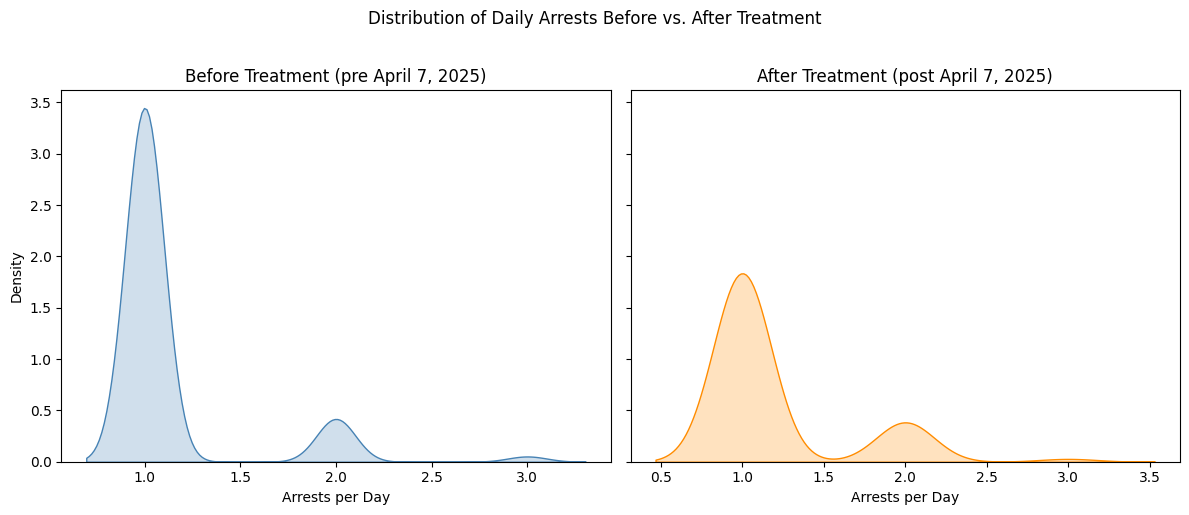

In [5]:
pre_daily = before_treatment.groupby(before_treatment['calltime'].dt.date).size()       # | Count arrests per day before the treatment | 
post_daily = after_treatment.groupby(after_treatment['calltime'].dt.date).size()        # |  Count arrests per day after the treatment | 

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)                            # | Plot side by side |

sns.kdeplot(pre_daily, fill=True, color='steelblue', ax=axes[0])
axes[0].set_title('Before Treatment (pre April 7, 2025)')
axes[0].set_xlabel('Arrests per Day')
axes[0].set_ylabel('Density')

sns.kdeplot(post_daily, fill=True, color='darkorange', ax=axes[1])
axes[1].set_title('After Treatment (post April 7, 2025)')
axes[1].set_xlabel('Arrests per Day')
axes[1].set_ylabel('Density')

plt.suptitle('Distribution of Daily Arrests Before vs. After Treatment', y=1.02)
plt.tight_layout()
plt.savefig('KDE_output.png', dpi=300)
plt.show()